In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"scvi-tools version: {scvi.__version__}")

PyTorch version: 2.6.0+cu124
scvi-tools version: 1.1.6.post2


In [1]:
#02/11/2024

import torch
import os
import scanpy as sc
import anndata
import numpy as np
import scvi
import logging
import matplotlib.pyplot as plt

# 1. Configurar logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# 2. Configurar PyTorch (intentar todas las opciones hasta que una funcione)
torch.backends.weights_only = False
os.environ['TORCH_WEIGHTS_ONLY'] = '0'
# Monkey patch si es necesario
original_torch_load = torch.load
torch.load = lambda *args, **kwargs: original_torch_load(*args, weights_only=False, **kwargs)

# Cargar el archivo h5ad integrado
input_path = '/app/project/restore_data/pipeline_articulo/4.models/scvi_model/scvi_integrated.h5ad'
logging.info(f"Cargando datos integrados desde: {input_path}")
adata = sc.read_h5ad(input_path)

# Cargar el modelo scVI previamente entrenado
scvi_model_path = '/app/project/restore_data/pipeline_articulo/4.models/scvi_model'
logging.info(f"Cargando modelo scVI desde: {scvi_model_path}")
scvi_model = scvi.model.SCVI.load(scvi_model_path, adata)

# Determinar el valor para células no etiquetadas
unlabeled_category = "Uncategorized"  # Ajusta esto según tus datos

# Configurar anndata para scANVI
logging.info("Configurando anndata para scANVI")
scvi.model.SCANVI.setup_anndata(
    adata,
    layer="counts",
    batch_key='short_title',
    labels_key='cell_type',
    unlabeled_category=unlabeled_category,
    categorical_covariate_keys=['assay', 'self_reported_ethnicity', 'sex']
)


# Crear y entrenar el modelo scANVI
logging.info("Creando y entrenando modelo scANVI")
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_model,
    adata=adata,
    labels_key='cell_type',
    unlabeled_category="Uncategorized"
)
scanvi_model.train(
    max_epochs=150,
    early_stopping=True,
    early_stopping_patience=15,
    n_samples_per_label=100,  # Balancear entrenamiento por tipo celular
    batch_size=256  # Ajustar según memoria disponible
)

# Guardar el modelo scANVI
scanvi_model_save_path = '/app/project/restore_data/pipeline_articulo/4.models/scanvi_model'
logging.info(f"Guardando modelo scANVI en: {scanvi_model_save_path}")
scanvi_model.save(scanvi_model_save_path, overwrite=True)

# Obtener representaciones latentes
SCANVI_LATENT_KEY = "X_scANVI"
adata.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation()

# Calcular vecinos y UMAP
logging.info("Calculando vecinos y UMAP")
sc.pp.neighbors(adata, use_rep=SCANVI_LATENT_KEY)
sc.tl.umap(adata)

# Ejecutar clustering de Leiden
logging.info("Ejecutando clustering de Leiden")
sc.tl.leiden(adata, key_added="scanvi_leiden")

# Crear directorio para guardar figuras si no existe
figures_dir = '/app/project/restore_data/pipeline_articulo/4.models/scanvi_model'
os.makedirs(figures_dir, exist_ok=True)

# Visualizar y guardar UMAP por muestra
logging.info("Generando y guardando UMAP por muestra")
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.umap(adata, color="short_title", ax=ax, show=False)
plt.title("scANVI UMAP por muestra")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'scanvi_umap_sample.png'))
plt.close()

# Visualizar y guardar UMAP por tipo de célula
logging.info("Generando y guardando UMAP por tipo de célula")
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.umap(adata, color="cell_type", ax=ax, show=False)
plt.title("scANVI UMAP por tipo de célula")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'scanvi_umap_cell_type.png'))
plt.close()

# Visualizar y guardar UMAP por clustering de Leiden
logging.info("Generando y guardando UMAP por clustering de Leiden")
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.umap(adata, color="scanvi_leiden", ax=ax, show=False)
plt.title("scANVI UMAP por clustering de Leiden")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'scanvi_umap_leiden.png'))
plt.close()

# Guardar el objeto AnnData actualizado
output_path = '/app/project/restore_data/pipeline_articulo/4.models/scanvi_model/scanvi_integrated.h5ad'
logging.info(f"Guardando objeto AnnData actualizado en: {output_path}")
adata.write(output_path)

logging.info("Proceso completado con éxito")

2025-02-10 07:09:41,386 - INFO - Cargando datos integrados desde: /app/project/restore_data/pipeline_articulo/4.models/scvi_model/scvi_integrated.h5ad
2025-02-10 07:12:42,125 - INFO - Cargando modelo scVI desde: /app/project/restore_data/pipeline_articulo/4.models/scvi_model
Trainer will use only 1 of 3 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=3)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /app/project/restore_data/pipeline_articulo/4.models/scvi_model/model.pt already downloaded          


2025-02-10 07:12:42,582 - INFO - Unable to initialize backend 'cuda': 
2025-02-10 07:12:42,584 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-02-10 07:12:42,735 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2025-02-10 07:12:42,736 - WARNING - An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
2025-02-10 07:12:46,977 - INFO - Configurando anndata para scANVI
2025-02-10 07:12:47,025 - INFO - Creando y entrenando modelo scANVI


INFO     Training for 150 epochs.                                                                                  


Trainer will use only 1 of 3 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=3)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers

Epoch 56/150:  37%|███▋      | 56/150 [1:09:27<1:56:35, 74.42s/it, v_num=1, train_loss_step=2e+3, train_loss_epoch=1.95e+3]   

2025-02-10 08:22:17,602 - INFO - Guardando modelo scANVI en: /app/project/restore_data/pipeline_articulo/4.models/scanvi_model



Monitored metric elbo_validation did not improve in the last 15 records. Best score: 2024.235. Signaling Trainer to stop.


2025-02-10 08:22:30,889 - INFO - Calculando vecinos y UMAP
2025-02-10 08:31:38,866 - INFO - Ejecutando clustering de Leiden
/tmp/ipykernel_14567/352530552.py:79: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added="scanvi_leiden")
2025-02-10 08:56:36,500 - INFO - Generando y guardando UMAP por muestra
2025-02-10 08:56:40,444 - INFO - Generando y guardando UMAP por tipo de célula
2025-02-10 08:56:43,630 - INFO - Generando y guardando UMAP por clustering de Leiden
2025-02-10 08:56:47,264 - INFO - Guardando objeto AnnData actualizado en: /app/project/restore_data/pipeline_articulo/4.models/scanvi_model/scanvi_integrated.h5ad
2025-02-10 09:05:30,390 - INFO - Proceso completado con éxito


In [6]:
# Agregar evaluación de métricas después de la integración
import scanpy as sc
adata = sc.read_h5ad('/app/project/restore_data/pipeline_articulo/4.models/scanvi_model/scanvi_integrated.h5ad')

#import scib
from scib_metrics.benchmark import Benchmarker, BioConservation

biocons = BioConservation(isolated_labels=False)
bm = Benchmarker(
    adata,
    batch_key="short_title",
    label_key="cell_type",
    embedding_obsm_keys=["X_pca", "X_scVI", "X_scANVI"],
    bio_conservation_metrics=biocons,
    n_jobs=-1
)

bm.benchmark()
results_df = bm.get_results(min_max_scale=False)
print(results_df)

/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
rics:   0%|          | 0/10 [00:00<?, ?it/s]
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/jax/_src/linear_util.py:192: DeprecationWarning: Passing arguments 'a', 'a_min', or 'a_max' to jax.numpy.clip is deprecated. Please use 'x', 'min', and 'max' respectively instead.
  ans = self.f(*args, **dict(self.params, **kwargs))

rics:  50%|█████     | 5/10 [1:29:36<1:11:45, 861.03s/it, Batch correction: ilisi_knn] 
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size 

INFO     activated type II NK T cell consists of a single batch or is too small. Skip.                             


/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)

rics:  60%|██████    | 6/10 [1:36:17<46:58, 704.55s/it, Batch correction: kbet_per_label]  
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/_graph_connectivity.py:30: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

rics:   0%|          | 0/10 [00:00<?, ?it/s]
                                                                                         
rics:  50%|█████     | 5/10 [10:05<08:03, 96.62s/it, Batch correction: ilisi_knn] 
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use

INFO     activated type II NK T cell consists of a single batch or is too small. Skip.                             


/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)

rics:  60%|██████    | 6/10 [16:24<12:50, 192.55s/it, Batch correction: kbet_per_label]
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/_graph_connectivity.py:30: FutureWarning: pandas.value_counts is deprecated and will b

INFO     activated type II NK T cell consists of a single batch or is too small. Skip.                             


/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)

rics:  60%|██████    | 6/10 [18:12<15:12, 228.22s/it, Batch correction: kbet_per_label]
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/_graph_connectivity.py:30: FutureWarning: pandas.value_counts is deprecated and will b

                   KMeans NMI        KMeans ARI  Silhouette label  \
Embedding                                                           
X_pca                0.216538          0.099207          0.457812   
X_scVI               0.082819          0.034202          0.501653   
X_scANVI             0.095413           0.04011          0.504086   
Metric Type  Bio conservation  Bio conservation  Bio conservation   

                        cLISI  Silhouette batch             iLISI  \
Embedding                                                           
X_pca                     1.0           0.73079               0.0   
X_scVI               0.894224          0.908617          0.056977   
X_scANVI             0.928504          0.891798          0.059677   
Metric Type  Bio conservation  Batch correction  Batch correction   

                         KBET Graph connectivity    PCR comparison  \
Embedding                                                            
X_pca                0.001826 

Tabla de resultados escalados


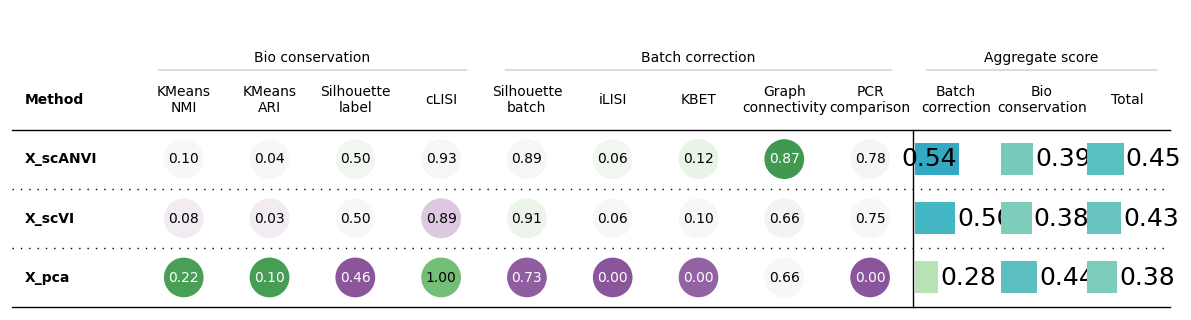

In [7]:


print('Tabla de resultados escalados')
bm.plot_results_table(min_max_scale=False)

/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/benchmark/_core.py:268: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/benchmark/_core.py:268: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/scib_metrics/benchmark/_core.py:268: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pan

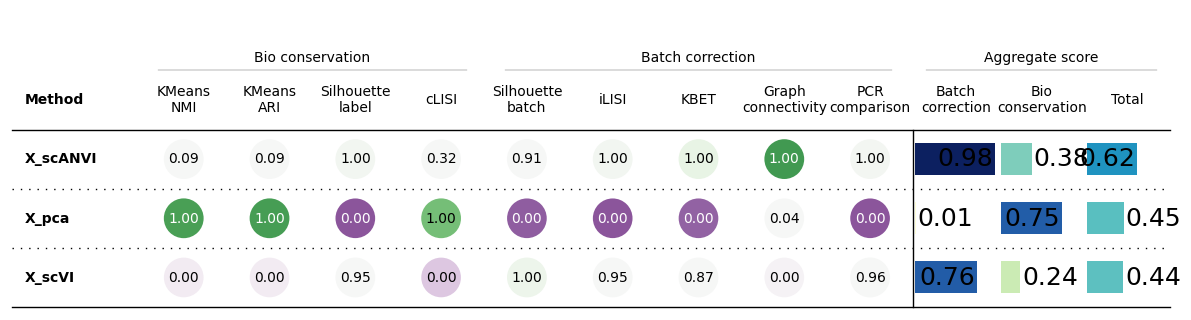

In [8]:
bm.plot_results_table()

In [9]:
adata

AnnData object with n_obs × n_vars = 339144 × 7000
    obs: 'dataset_id', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'cell_group', 'age_yrs', 'age_group', 'source_file', 'title', 'short_title', 'batch', 'n_genes_by_counts', 'total_counts', 'n_genes', 'n_counts', 'percent_mito', 'percent_ribo', 'complexity', '_scvi_batch', '_scvi_labels', 'doublet_score', 'singlet_score', 'doublet_prediction', 'leiden', 'scanvi_leiden'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_length', 'nnz', 'n_measured_obs', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'genome', 'hvg', 'hvg_genes', 'leiden', 'leiden_colors', 'log1p', 'modality', 'neighbors', 'pca', 'processing_info', 'short_title_colors', 'source_file

In [ ]:
#Benchmarking de los métodos
import scanpy as sc
import scib
from scib_metrics.benchmark import Benchmarker, BioConservation
import numpy as np
import matplotlib.pyplot as plt
import logging


####################################  
'''

import faiss

from scib_metrics.nearest_neighbors import NeighborsResults


def faiss_hnsw_nn(X: np.ndarray, k: int):
    """Gpu HNSW nearest neighbor search using faiss.

    See https://github.com/nmslib/hnswlib/blob/master/ALGO_PARAMS.md
    for index param details.
    """
    X = np.ascontiguousarray(X, dtype=np.float32)
    res = faiss.StandardGpuResources()
    M = 32
    index = faiss.IndexHNSWFlat(X.shape[1], M, faiss.METRIC_L2)
    gpu_index = faiss.index_cpu_to_gpu(res, 0, index)
    gpu_index.add(X)
    distances, indices = gpu_index.search(X, k)
    del index
    del gpu_index
    # distances are squared
    return NeighborsResults(indices=indices, distances=np.sqrt(distances))


def faiss_brute_force_nn(X: np.ndarray, k: int):
    """Gpu brute force nearest neighbor search using faiss."""
    X = np.ascontiguousarray(X, dtype=np.float32)
    res = faiss.StandardGpuResources()
    index = faiss.IndexFlatL2(X.shape[1])
    gpu_index = faiss.index_cpu_to_gpu(res, 0, index)
    gpu_index.add(X)
    distances, indices = gpu_index.search(X, k)
    del index
    del gpu_index
    # distances are squared
    return NeighborsResults(indices=indices, distances=np.sqrt(distances))

###################################    
'''

# Configurar logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Cargar los datos integrados
input_path = '/app/project/test_data/pipeline_colombia/4.models/scanvi_model/scanvi_integrated.h5ad'
logging.info(f"Cargando datos integrados desde: {input_path}")
adata = sc.read_h5ad(input_path)

# Asegurarse de que tenemos las representaciones no integradas
if "X_pca" not in adata.obsm:
    logging.info("Calculando PCA para datos no integrados")
    sc.pp.pca(adata)
adata.obsm["Unintegrated"] = adata.obsm["X_pca"]

#scVI

adata.obsm["scVI"] = adata.obsm["X_scVI"]

#scANVI

adata.obsm["scANVI"] = adata.obsm["X_scANVI"]


# Configurar el objeto Benchmarker
logging.info("Configurando el objeto Benchmarker")
biocons = BioConservation(isolated_labels=False)
bm = Benchmarker(
    adata,
    batch_key= "short_title",
    label_key="cell_type",
    embedding_obsm_keys=["Unintegrated", "scVI", "scANVI"],
    pre_integrated_embedding_obsm_key="X_pca",
    bio_conservation_metrics=biocons,
    n_jobs=3,
)


# Ejecutar las métricas de benchmarking
logging.info("Ejecutando métricas de benchmarking")
bm.prepare()  #neighbor_computer=faiss_brute_force_nn
bm.benchmark()

# Visualizar los resultados
logging.info("Generando visualizaciones de los resultados")
plt.figure(figsize=(12, 8))
bm.plot_results_table()
plt.tight_layout()
plt.savefig('/app/project/test_data/pipeline_colombia/4.models/scanvi_model/integration_metrics.png')
plt.close()

# Obtener y guardar los resultados como CSV
results_df = bm.get_results(min_max_scale=False)
results_df.to_csv('/app/project/test_data/pipeline_colombia/4.models/scanvi_model/integration_metrics_results.csv')

logging.info("Imprimiendo resultados:")
print(results_df)
logging.info("Evaluación de métricas de integración completada")

# Visualizaciones adicionales
# UMAP por batch y tipo celular
logging.info("Generando visualizaciones UMAP")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sc.pl.umap(adata, color="short_title", ax=ax1, show=False, title="UMAP por batch")
sc.pl.umap(adata, color="cell_type", ax=ax2, show=False, title="UMAP por tipo celular")
plt.tight_layout()
plt.savefig('/app/project/test_data/pipeline_colombia/4.models/scanvi_model/umap_visualization.png')
plt.close()

# Información adicional del dataset
logging.info(f"Número total de células: {adata.n_obs}")
logging.info(f"Número de genes: {adata.n_vars}")
logging.info(f"Número de batches: {adata.obs['short_title'].nunique()}")
logging.info(f"Tipos celulares: {adata.obs['cell_type'].unique()}")


print('Tabla de resultados escalados')
bm.plot_results_table(min_max_scale=False)